In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
# Write your code here
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# more plotly imports
from plotly.offline import init_notebook_mode, iplot, plot
init_notebook_mode(connected=True)
import plotly as py
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots


# load main dataset
df = pd.read_csv('./drive/MyDrive/games_march2025_cleaned.csv', engine='python', on_bad_lines='skip')

Mounted at /content/drive


In [ ]:
df.head()


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [ ]:
# Select useful columns
columns_to_keep = [
    'name', 'release_date', 'required_age', 'price', 'dlc_count',
    'detailed_description', 'metacritic_score', 'recommendations',
    'genres', 'categories',
    'positive', 'negative', 'estimated_owners',
    'average_playtime_forever', 'median_playtime_forever', 'peak_ccu',
    'tags', 'pct_pos_total', 'num_reviews_total'
]

# Create a filtered version of the dataframe
df_ml = df[columns_to_keep].copy()
df = df_ml.dropna(subset=['detailed_description'])
df.info()
df.head()
df.tail()


<class 'pandas.core.frame.DataFrame'>
Index: 89421 entries, 0 to 89617
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      89421 non-null  object 
 1   release_date              89421 non-null  object 
 2   required_age              89421 non-null  int64  
 3   price                     89421 non-null  float64
 4   dlc_count                 89421 non-null  int64  
 5   detailed_description      89421 non-null  object 
 6   metacritic_score          89421 non-null  int64  
 7   recommendations           89421 non-null  int64  
 8   genres                    89421 non-null  object 
 9   categories                89421 non-null  object 
 10  positive                  89421 non-null  int64  
 11  negative                  89421 non-null  int64  
 12  estimated_owners          89421 non-null  object 
 13  average_playtime_forever  89421 non-null  int64  
 14  median_play

,name,release_date,required_age,price,dlc_count,detailed_description,metacritic_score,recommendations,genres,categories,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total
89613,Outrun Them,2024-02-29,0,3.99,0,The name of the game is literally the game. Ou...,0,0,"['Indie', 'Early Access']","['Single-player', 'Steam Achievements', 'Stats...",2,0,0 - 20000,0,0,0,"{'2D Platformer': 91, 'Runner': 85, 'Platforme...",-1,-1
89614,Lands of Pharaoh: Episode 1,2020-01-07,0,10.00,0,Join Our Discord Channel About the Game Briefl...,0,0,"['Action', 'Adventure', 'Indie', 'Strategy']","['Single-player', 'Family Sharing']",2,0,0 - 20000,0,0,0,"{'Action': 43, 'Adventure': 41, 'Indie': 41, '...",-1,-1
89615,Player One,2019-10-10,0,1.99,0,Player One is a new 3D game where you take con...,0,0,"['Indie', 'Early Access']","['Single-player', 'Family Sharing']",2,1,0 - 20000,0,0,0,"{'Indie': 31, 'Early Access': 21}",-1,-1
89616,DragonRoad,2025-01-25,0,29.99,0,"This is an open world game on 3D, also a m...",0,0,"['Adventure', 'RPG', 'Simulation', 'Strategy']","['Single-player', 'Multi-player', 'PvP', 'Onli...",2,0,0 - 20000,0,0,0,"{'RPG': 117, 'Action-Adventure': 111, 'Strateg...",-1,-1
89617,Ragtag Adventurers,2018-03-01,0,9.99,0,Ragtag Adventurers is a Boss Rush game that pi...,0,0,"['Action', 'Indie']","['Single-player', 'Multi-player', 'PvP', 'Onli...",8,4,0 - 20000,0,0,0,"{'Action': 22, 'Indie': 21}",-1,-1


,metacritic_score
count,3538.000000
mean,73.339175
std,10.223056
min,20.000000
25%,68.000000
50%,75.000000
75%,81.000000
max,97.000000


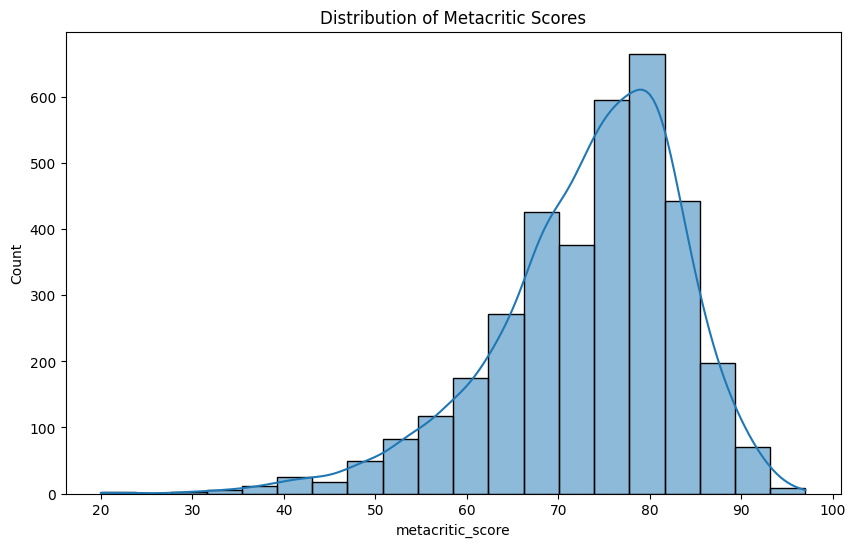

,name,release_date,required_age,price,dlc_count,detailed_description,metacritic_score,recommendations,genres,categories,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total
2,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...",90,14337,"['Action', 'Strategy', 'Free To Play']","['Multi-player', 'Co-op', 'Steam Trading Cards...",1998462,451338,200000000 - 500000000,43031,898,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595
3,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...",96,1803063,"['Action', 'Adventure']","['Single-player', 'Multi-player', 'PvP', 'Onli...",1719950,250012,50000000 - 100000000,19323,7101,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832
5,Team Fortress 2,2007-10-10,0,0.00,1,'The most fun you can have online' - PC Gamer ...,92,41587,"['Action', 'Free To Play']","['Multi-player', 'Cross-Platform Multiplayer',...",1025633,120619,20000000 - 50000000,0,0,50817,"{'Free to Play': 62868, 'Hero Shooter': 61020,...",89,1146642
6,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...",83,1098792,"['Action', 'Adventure', 'Indie', 'RPG']","['Single-player', 'Multi-player', 'PvP', 'Onli...",1344773,34460,20000000 - 50000000,0,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434
7,Rust,2018-02-08,0,39.99,4,The only aim in Rust is to survive. Everything...,69,992825,"['Action', 'Adventure', 'Indie', 'Massively Mu...","['Multi-player', 'MMO', 'PvP', 'Online PvP', '...",1043708,152272,20000000 - 50000000,21195,3675,200902,"{'Survival': 18592, 'Crafting': 11822, 'Multip...",87,993856


In [ ]:
# Filter the dataframe to only include games with a Metacritic score
df_rated = df[df['metacritic_score'] > 0].copy()
display(df_rated['metacritic_score'].describe())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_rated['metacritic_score'], bins=20, kde=True)
plt.title('Distribution of Metacritic Scores')
plt.show()
df_rated.head()

### TF-IDF Analysis on Game Descriptions
We will use the text in `detailed_description` to see if we can predict the `metacritic_score`.

In [ ]:
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

# Basic Preprocessing
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]", "", text)
    return text

df_rated['processed_description'] = df_rated['detailed_description'].apply(preprocess_text)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df_rated['processed_description'],
    df_rated['metacritic_score'],
    test_size=0.2,
    random_state=42
)

# Pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        stop_words='english',
        ngram_range=(1, 3),
        min_df=3
    )),
    ("ridge", RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]))
])

# Cross-Validation on training set
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

cv_mae_scores = -cv_scores

print(f"\nCross-Validation MAE: {cv_mae_scores.mean():.2f} ± {cv_mae_scores.std():.2f}")

#Train Final Model
pipeline.fit(X_train, y_train)

# Test Set Evaluation
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal Test Performance:")
print(f"Test MAE: {mae:.2f}")
print(f"Test R^2: {r2:.4f}")

# Baseline Comparison
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")

#Feature Importance
tfidf = pipeline.named_steps['tfidf']
ridge = pipeline.named_steps['ridge']

feature_names = tfidf.get_feature_names_out()
coefs = ridge.coef_

word_importance = pd.DataFrame({
    'term': feature_names,
    'coefficient': coefs
})

print("\nTop 10 Terms Associated with HIGHER Scores:")
print(word_importance.sort_values(by='coefficient', ascending=False).head(10))

print("\nTop 10 Terms Associated with LOWER Scores:")
print(word_importance.sort_values(by='coefficient', ascending=True).head(10))


Cross-Validation MAE: 7.50 ± 0.37

Final Test Performance:
Test MAE: 7.42
Test R^2: 0.1509
Baseline MAE: 8.14

Top 10 Terms Associated with HIGHER Scores:
             term  coefficient
763        awards    10.910201
7033  puzzle game    10.882150
6633         play    10.311037
2794      edition    10.060718
5718       monkey     9.967705
1728    community     9.483650
5928          new     9.475105
1209        built     9.195115
2093       custom     9.044750
7961         sims     8.958891

Top 10 Terms Associated with LOWER Scores:
            term  coefficient
5639    missions   -15.586086
2435   different   -15.257147
8189     special   -13.378267
3365    features   -13.159538
6368  painkiller   -12.650135
9930       xenos   -11.677991
8336     stealth   -11.240237
9991      zombie   -10.822377
4377      hockey   -10.599810
7875     shelter   -10.581243


Here we can see that specific descriptions such as "puzzle game" or "community" correlate to higher scores, so players probably like puzzle games and community support. Terms like "edition" and "awards" likely sway player opinion by suggesting the game is good enough to have multiple editions and awards. "New" is also present, so people like to see innovation.

On the other hand, generic terms like "missions" or "special" or even "zombies" seem to hurt scores.

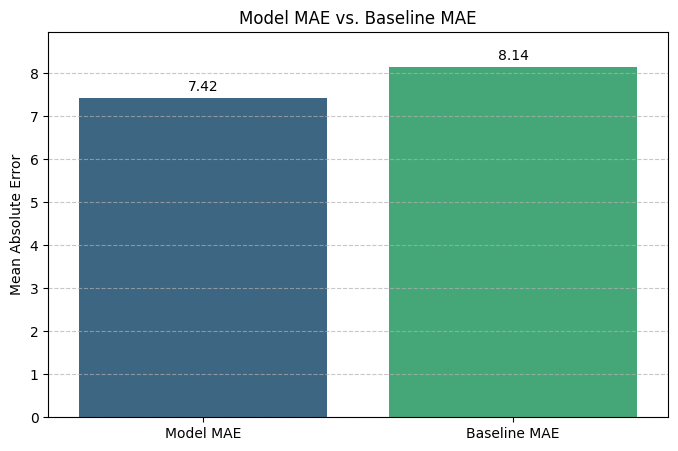

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Model MAE', 'Baseline MAE']
values = [mae, baseline_mae]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, hue=metrics, palette='viridis', legend=False)
plt.title('Model MAE vs. Baseline MAE')
plt.ylabel('Mean Absolute Error')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(values):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

plt.ylim(0, max(values) * 1.1)
plt.show()

Our model performs better than baseline predictions, better by about 0.7 Metacritic points.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
# Write your code here
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# more plotly imports
from plotly.offline import init_notebook_mode, iplot, plot
init_notebook_mode(connected=True)
import plotly as py
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots


# load main dataset
df = pd.read_csv('./drive/MyDrive/games_march2025_cleaned.csv', engine='python', on_bad_lines='skip')

Mounted at /content/drive


In [ ]:
df.head()


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [ ]:
# Select useful columns
columns_to_keep = [
    'name', 'release_date', 'required_age', 'price', 'dlc_count',
    'detailed_description', 'metacritic_score', 'recommendations',
    'genres', 'categories',
    'positive', 'negative', 'estimated_owners',
    'average_playtime_forever', 'median_playtime_forever', 'peak_ccu',
    'tags', 'pct_pos_total', 'num_reviews_total'
]

# Create a filtered version of the dataframe
df_ml = df[columns_to_keep].copy()
df = df_ml.dropna(subset=['detailed_description'])
df.info()
df.head()
df.tail()


<class 'pandas.core.frame.DataFrame'>
Index: 89421 entries, 0 to 89617
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      89421 non-null  object 
 1   release_date              89421 non-null  object 
 2   required_age              89421 non-null  int64  
 3   price                     89421 non-null  float64
 4   dlc_count                 89421 non-null  int64  
 5   detailed_description      89421 non-null  object 
 6   metacritic_score          89421 non-null  int64  
 7   recommendations           89421 non-null  int64  
 8   genres                    89421 non-null  object 
 9   categories                89421 non-null  object 
 10  positive                  89421 non-null  int64  
 11  negative                  89421 non-null  int64  
 12  estimated_owners          89421 non-null  object 
 13  average_playtime_forever  89421 non-null  int64  
 14  median_play

,name,release_date,required_age,price,dlc_count,detailed_description,metacritic_score,recommendations,genres,categories,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total
89613,Outrun Them,2024-02-29,0,3.99,0,The name of the game is literally the game. Ou...,0,0,"['Indie', 'Early Access']","['Single-player', 'Steam Achievements', 'Stats...",2,0,0 - 20000,0,0,0,"{'2D Platformer': 91, 'Runner': 85, 'Platforme...",-1,-1
89614,Lands of Pharaoh: Episode 1,2020-01-07,0,10.00,0,Join Our Discord Channel About the Game Briefl...,0,0,"['Action', 'Adventure', 'Indie', 'Strategy']","['Single-player', 'Family Sharing']",2,0,0 - 20000,0,0,0,"{'Action': 43, 'Adventure': 41, 'Indie': 41, '...",-1,-1
89615,Player One,2019-10-10,0,1.99,0,Player One is a new 3D game where you take con...,0,0,"['Indie', 'Early Access']","['Single-player', 'Family Sharing']",2,1,0 - 20000,0,0,0,"{'Indie': 31, 'Early Access': 21}",-1,-1
89616,DragonRoad,2025-01-25,0,29.99,0,"This is an open world game on 3D, also a m...",0,0,"['Adventure', 'RPG', 'Simulation', 'Strategy']","['Single-player', 'Multi-player', 'PvP', 'Onli...",2,0,0 - 20000,0,0,0,"{'RPG': 117, 'Action-Adventure': 111, 'Strateg...",-1,-1
89617,Ragtag Adventurers,2018-03-01,0,9.99,0,Ragtag Adventurers is a Boss Rush game that pi...,0,0,"['Action', 'Indie']","['Single-player', 'Multi-player', 'PvP', 'Onli...",8,4,0 - 20000,0,0,0,"{'Action': 22, 'Indie': 21}",-1,-1


,metacritic_score
count,3538.000000
mean,73.339175
std,10.223056
min,20.000000
25%,68.000000
50%,75.000000
75%,81.000000
max,97.000000


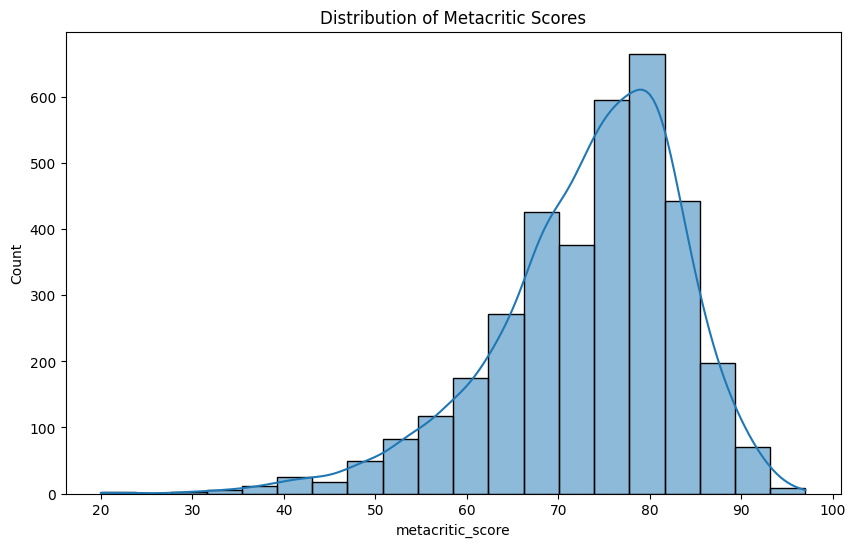

,name,release_date,required_age,price,dlc_count,detailed_description,metacritic_score,recommendations,genres,categories,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total
2,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...",90,14337,"['Action', 'Strategy', 'Free To Play']","['Multi-player', 'Co-op', 'Steam Trading Cards...",1998462,451338,200000000 - 500000000,43031,898,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595
3,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...",96,1803063,"['Action', 'Adventure']","['Single-player', 'Multi-player', 'PvP', 'Onli...",1719950,250012,50000000 - 100000000,19323,7101,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832
5,Team Fortress 2,2007-10-10,0,0.00,1,'The most fun you can have online' - PC Gamer ...,92,41587,"['Action', 'Free To Play']","['Multi-player', 'Cross-Platform Multiplayer',...",1025633,120619,20000000 - 50000000,0,0,50817,"{'Free to Play': 62868, 'Hero Shooter': 61020,...",89,1146642
6,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...",83,1098792,"['Action', 'Adventure', 'Indie', 'RPG']","['Single-player', 'Multi-player', 'PvP', 'Onli...",1344773,34460,20000000 - 50000000,0,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434
7,Rust,2018-02-08,0,39.99,4,The only aim in Rust is to survive. Everything...,69,992825,"['Action', 'Adventure', 'Indie', 'Massively Mu...","['Multi-player', 'MMO', 'PvP', 'Online PvP', '...",1043708,152272,20000000 - 50000000,21195,3675,200902,"{'Survival': 18592, 'Crafting': 11822, 'Multip...",87,993856


In [ ]:
# Filter the dataframe to only include games with a Metacritic score
df_rated = df[df['metacritic_score'] > 0].copy()
display(df_rated['metacritic_score'].describe())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_rated['metacritic_score'], bins=20, kde=True)
plt.title('Distribution of Metacritic Scores')
plt.show()
df_rated.head()

### TF-IDF Analysis on Game Descriptions
We will use the text in `detailed_description` to see if we can predict the `metacritic_score`.

In [ ]:
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

# Basic Preprocessing
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]", "", text)
    return text

df_rated['processed_description'] = df_rated['detailed_description'].apply(preprocess_text)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df_rated['processed_description'],
    df_rated['metacritic_score'],
    test_size=0.2,
    random_state=42
)

# Pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        stop_words='english',
        ngram_range=(1, 3),
        min_df=3
    )),
    ("ridge", RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]))
])

# Cross-Validation on training set
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

cv_mae_scores = -cv_scores

print(f"\nCross-Validation MAE: {cv_mae_scores.mean():.2f} ± {cv_mae_scores.std():.2f}")

#Train Final Model
pipeline.fit(X_train, y_train)

# Test Set Evaluation
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal Test Performance:")
print(f"Test MAE: {mae:.2f}")
print(f"Test R^2: {r2:.4f}")

# Baseline Comparison
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")

#Feature Importance
tfidf = pipeline.named_steps['tfidf']
ridge = pipeline.named_steps['ridge']

feature_names = tfidf.get_feature_names_out()
coefs = ridge.coef_

word_importance = pd.DataFrame({
    'term': feature_names,
    'coefficient': coefs
})

print("\nTop 10 Terms Associated with HIGHER Scores:")
print(word_importance.sort_values(by='coefficient', ascending=False).head(10))

print("\nTop 10 Terms Associated with LOWER Scores:")
print(word_importance.sort_values(by='coefficient', ascending=True).head(10))


Cross-Validation MAE: 7.50 ± 0.37

Final Test Performance:
Test MAE: 7.42
Test R^2: 0.1509
Baseline MAE: 8.14

Top 10 Terms Associated with HIGHER Scores:
             term  coefficient
763        awards    10.910201
7033  puzzle game    10.882150
6633         play    10.311037
2794      edition    10.060718
5718       monkey     9.967705
1728    community     9.483650
5928          new     9.475105
1209        built     9.195115
2093       custom     9.044750
7961         sims     8.958891

Top 10 Terms Associated with LOWER Scores:
            term  coefficient
5639    missions   -15.586086
2435   different   -15.257147
8189     special   -13.378267
3365    features   -13.159538
6368  painkiller   -12.650135
9930       xenos   -11.677991
8336     stealth   -11.240237
9991      zombie   -10.822377
4377      hockey   -10.599810
7875     shelter   -10.581243


Here we can see that specific descriptions such as "puzzle game" or "community" correlate to higher scores, so players probably like puzzle games and community support. Terms like "edition" and "awards" likely sway player opinion by suggesting the game is good enough to have multiple editions and awards. "New" is also present, so people like to see innovation.

On the other hand, generic terms like "missions" or "special" or even "zombies" seem to hurt scores.

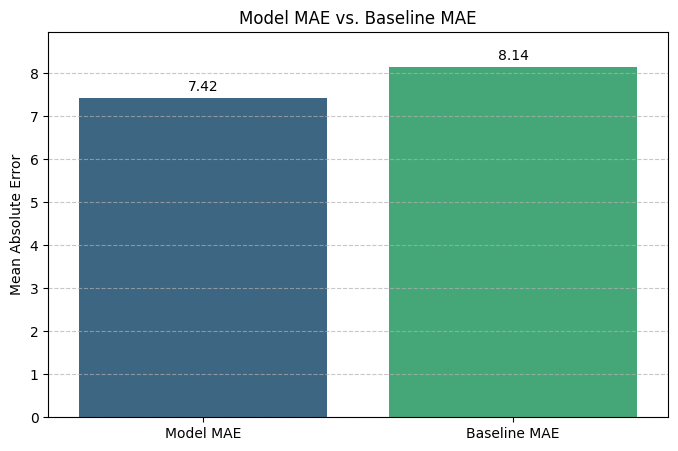

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Model MAE', 'Baseline MAE']
values = [mae, baseline_mae]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, hue=metrics, palette='viridis', legend=False)
plt.title('Model MAE vs. Baseline MAE')
plt.ylabel('Mean Absolute Error')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(values):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

plt.ylim(0, max(values) * 1.1)
plt.show()

Our model performs better than baseline predictions, better by about 0.7 Metacritic points.